In [1]:
import pandas as pd

# 1. Create a realistic sample of e-commerce data (including some missing Customer IDs!)
data = {
    'InvoiceNo': ['536365', '536366', '536367', '536368', '536369', '536370', '536371'],
    'Quantity': [6, 8, 6, 3, 2, 1, 4],
    'InvoiceDate': ['12/1/2023 8:26', '12/2/2023 8:28', '12/3/2023 8:34', '12/5/2023 9:00', '12/10/2023 10:00', '12/15/2023 11:30', '12/20/2023 12:00'],
    'UnitPrice': [2.55, 2.75, 3.39, 4.25, 7.65, 1.50, 2.00],
    'CustomerID': [17850, 17850, 13047, None, 13047, 12583, None] 
}

# 2. Save it as a real CSV file in your VS Code folder
temp_df = pd.DataFrame(data)
temp_df.to_csv('ecommerce_data.csv', index=False)

# 3. Load the local file (this is how you will do it 99% of the time on the job)
df = pd.read_csv('ecommerce_data.csv')

# Show the table!
df.head(10)

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,12/1/2023 8:26,2.55,17850.0
1,536366,8,12/2/2023 8:28,2.75,17850.0
2,536367,6,12/3/2023 8:34,3.39,13047.0
3,536368,3,12/5/2023 9:00,4.25,NaN
4,536369,2,12/10/2023 10:00,7.65,13047.0
5,536370,1,12/15/2023 11:30,1.50,12583.0
6,536371,4,12/20/2023 12:00,2.00,NaN


In [2]:
# 1. Check how many missing values exist in each column before cleaning
print("Missing values before:\n", df.isnull().sum())

# 2. Drop any row where the 'CustomerID' is missing (NaN)
df_clean = df.dropna(subset=['CustomerID'])

# 3. Check again to prove they are gone
print("\nMissing values after:\n", df_clean.isnull().sum())

# Display the newly cleaned dataset
df_clean

Missing values before:
 InvoiceNo      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     2
dtype: int64

Missing values after:
 InvoiceNo      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
dtype: int64


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,12/1/2023 8:26,2.55,17850.0
1,536366,8,12/2/2023 8:28,2.75,17850.0
2,536367,6,12/3/2023 8:34,3.39,13047.0
4,536369,2,12/10/2023 10:00,7.65,13047.0
5,536370,1,12/15/2023 11:30,1.50,12583.0


In [3]:
# 1. Create a safe copy of our clean data to avoid Pandas memory warnings
df_clean = df_clean.copy()

# 2. Multiply Quantity by UnitPrice to get the total spent per transaction
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 3. Group the data by CustomerID and sum up all their purchases
# This is the exact equivalent of an Excel Pivot Table!
customer_spend = df_clean.groupby('CustomerID')['TotalSpend'].sum().reset_index()

# 4. Rename the column to 'Monetary' for our RFM model
customer_spend.rename(columns={'TotalSpend': 'Monetary'}, inplace=True)

# Display the total lifetime value of our customers
customer_spend

,CustomerID,Monetary
0,12583.0,1.50
1,13047.0,35.64
2,17850.0,37.30


In [4]:
# 1. Convert the 'InvoiceDate' column from plain text into proper datetime objects
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Set a "snapshot date" (Let's pretend today is exactly 1 day after the most recent purchase)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# 3. Calculate R, F, and M all at once using .agg()
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                   # Frequency: Count of unique invoices
    'TotalSpend': 'sum'                                       # Monetary: Sum of total money spent
}).reset_index()

# 4. Rename the columns so they are clean and readable
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

# Display the final RFM summary table!
rfm

,CustomerID,Recency,Frequency,Monetary
0,12583.0,1,1,1.50
1,13047.0,6,2,35.64
2,17850.0,14,2,37.30


In [5]:
# The exclamation mark tells VS Code to run this in the terminal in the background
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 174.3 kB/s eta 0:00:52
   -- ------------------------------------- 0.5/9.5 MB 174.3 kB/s eta 0:00:52
   -- ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


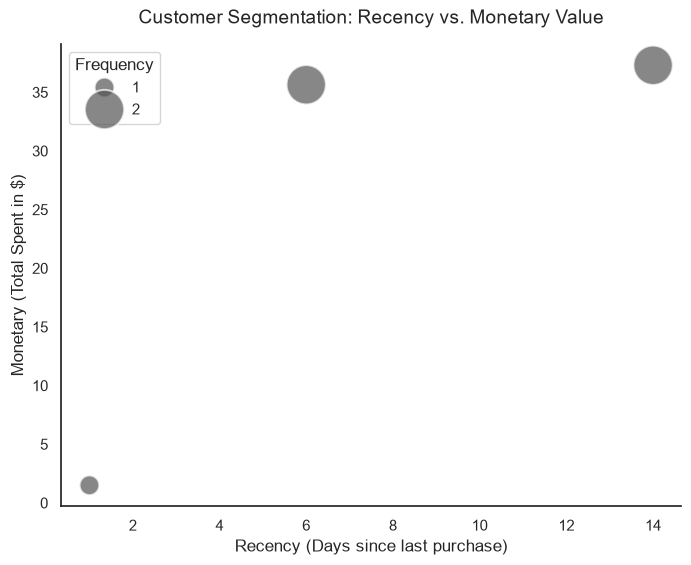

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, neutral background aesthetic
sns.set_theme(style="white")

# 2. Set the size of the canvas
plt.figure(figsize=(8, 6))

# 3. Create a scatter plot 
# X-axis = Recency, Y-axis = Monetary, Bubble Size = Frequency
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    size='Frequency',
    sizes=(200, 800), # Makes the bubbles large enough to see
    alpha=0.7,        # Adds slight transparency
    color='#555555'   # A sleek, neutral dark gray
)

# 4. Strip away the top and right borders to remove visual clutter
sns.despine()

# 5. Add clear, simple labels
plt.title('Customer Segmentation: Recency vs. Monetary Value', fontsize=14, pad=15)
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary (Total Spent in $)', fontsize=12)

# 6. Display the chart
plt.show()